1. Convert the tokens in the third caption for the second image in the test set into a sequence of integers. Name the sequence indices2. Print out the values in indices2.

In [1]:
!pip install torchvision

In [2]:
import kagglehub, shutil

path = kagglehub.dataset_download("adityajn105/flickr8k")
shutil.copytree("/kaggle/input/flickr8k/Images","files/Images")

Using Colab cache for faster access to the 'flickr8k' dataset.


'files/Images'

In [9]:
import gdown #ATENTIE TREBUIE PUSA PRIMA COMANDA DE IMPORT DUPA CARE TREBUIE FACUTA DESCARCAREA DE PE DRIVE SI APOI JSON
import os

# Creăm folderul 'files' dacă nu există
os.makedirs('files', exist_ok=True)

# URL-ul de Google Drive (extras ID-ul din link)
file_id = '1ZUNdI3kw3yP20PYoQpQ8_9KbptFX7cJG'
drive_url = f'https://drive.google.com/uc?id={file_id}'
output = 'files/dataset_flickr8k.json'

# Descărcăm fișierul
gdown.download(drive_url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1ZUNdI3kw3yP20PYoQpQ8_9KbptFX7cJG
To: /content/files/dataset_flickr8k.json
100%|██████████| 9.04M/9.04M [00:00<00:00, 236MB/s]


'files/dataset_flickr8k.json'

In [10]:
import json

# Citim fișierul JSON
with open('files/dataset_flickr8k.json', 'r') as fb:
    data = json.load(fb)

print("Fișierul JSON a fost încărcat cu succes!")
# Afișăm structura de bază pentru verificare
print(f"Chei disponibile în date: {list(data.keys())}")

Fișierul JSON a fost încărcat cu succes!
Chei disponibile în date: ['images', 'dataset']


In [11]:
from collections import Counter

train_image_paths = []
train_image_captions = []
test_image_paths = []
test_image_captions = []
word_freq = Counter()

max_len=50
for img in data['images']:
    captions = []
    for c in img['sentences']:
        word_freq.update(c['tokens']) #Gathers information about text tokens to create a vocabulary
        if len(c['tokens']) <= max_len:
            captions.append(c['tokens']) #Gathers all captions
    if len(captions) == 0:
        continue
    path ="files/Images/"+img['filename']
    if img['split'] in {'train', 'val', 'restval'}: #Creates a train subset
        train_image_paths.append(path)
        train_image_captions.append(captions)
    elif img['split'] in {'test'}: #Creates a test subset
        test_image_paths.append(path)
        test_image_captions.append(captions)

In [12]:
assert len(train_image_paths)==len(train_image_captions)
assert len(test_image_paths)==len(test_image_captions)
print(f"there are {len(train_image_paths)} training images")
print(f"there are {len(test_image_paths)} test images")

there are 7000 training images
there are 1000 test images


In [13]:
min_word_freq=0
words = [w for w in word_freq.keys() if word_freq[w]>min_word_freq]
word2idx = {k:v + 4 for v,k in enumerate(words)} #Creates a dictionary to map tokens to indices
word2idx['<pad>'] = 0 # Hardcodes in the special tokens
word2idx['<start>'] = 1
word2idx['<end>'] = 2
word2idx['<unk>'] = 3

In [14]:
indices=[word2idx.get(token,3) for
         token in test_image_captions[0][0]]
print(indices)

[12, 18, 318, 11, 12, 13, 11, 45, 30, 4, 234]


In [18]:
idx2word={v:k for k, v in word2idx.items()} #Creates a dictionary idx2word to map indices to tokens
tokens=[idx2word.get(idx,"<unk>") for
         idx in indices] #Converts the sequence of indices to tokens using the dictionary
print(tokens)
print(f"there are {len(idx2word)} unique tokens")

['the', 'dogs', 'are', 'in', 'the', 'snow', 'in', 'front', 'of', 'a', 'fence']
there are 8387 unique tokens


In [17]:
indices2=[word2idx.get(token,3) for token in test_image_captions[1][2]]#aici--------------------------------------------
print(indices2)
#setul flick8k are un set de antrenament si un set de test
#fiecare set are un mii de poze
#fiecare poza are 5 descrieri diferite
#noi trebuie sa luam a 2 a poza din primul set(cel de antrenament) si sa ii printam a 3 a descriere

[4, 6, 1761, 11, 4, 713, 75, 4, 94]


2. Use the dictionary idx2word to convert the sequence of integers, indices2, that you generated in Exercise 1 into a sequence of tokens.

In [23]:
idx2word={v:k for k, v in word2idx.items()} #Creates a dictionary idx2word to map indices to tokens
tokens=[idx2word.get(idx,"<unk>") for
         idx in indices2] #Converts the sequence of indices to tokens using the dictionary
print(tokens)
print(f"there are {len(idx2word)} unique tokens")

print(" ".join(tokens))

#practic vream sa convertim lista de cifre in lista de cuvinte

['a', 'dog', 'swims', 'in', 'a', 'pool', 'near', 'a', 'person']
there are 8387 unique tokens
a dog swims in a pool near a person


3. Apply the compare() function on the  10 th image in the test set, and set the temp argument to 0.95.

In [24]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

def center_crop(img):
    width, height = img.size
    new=min(width,height)
    left = (width - new)/2
    top = (height - new)/2
    right = (width + new)/2
    bottom = (height + new)/2
    im = img.crop((left, top, right, bottom))
    return im

class FlickrD(Dataset):
    def __init__(self,images,captions,word2idx):
        self.images=images
        self.captions=captions
        self.word2idx=word2idx
        self._max_len = 50
        self.image_size=128
        self._image_transform = self._construct_image_transform(self.image_size)
        self._data = self._create_input_label_mappings()
        self._dataset_size = len(self._data)
        self._start_idx = 1
        self._end_idx = 2
        self._pad_idx = 0
        self._UNK_idx = 3
        self._START_token = "<start>"
        self._END_token = "<end>"
        self._PAD_token = "<pad>"
        self._UNK_token = "<unk>"

    def _construct_image_transform(self, image_size):
        # ImageNet normalization statistics
        normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225])
        preprocessing = transforms.Compose([
            transforms.ToTensor(),
            normalize,])
        return preprocessing
    def _load_and_process_images(self):
        # Load images
        images_raw = [center_crop(Image.open(path)).resize((self.image_size,
           self.image_size)) for path in self.images]
        # Adapt the images to CNN trained on ImageNet { PIL -> Tensor }
        image_tensors = [self._image_transform(img) for img in images_raw]
        images_processed = {img_name: img_tensor for img_name, img_tensor
                            in zip(self.images, image_tensors)}
        return images_processed

    def _group_captions(self):
        grouped_captions = {self.images[i]:self.captions[i]
                            for i in range(len(self.images))}
        return grouped_captions
    def _create_input_label_mappings(self):
        processed_data = []
        for img, caps in self._group_captions().items():
            for cap in caps:
                pair = (img, cap)
                processed_data.append(pair)
        return processed_data


    def _load_and_prepare_image(self, image_name):
        img_pil = center_crop(Image.open(image_name)).resize((self.image_size,
             self.image_size))
        image_tensor = self._image_transform(img_pil)
        return image_tensor


    def __len__(self):
        return self._dataset_size

    def __getitem__(self, index):
        # Extract the caption data
        image_id, tokens = self._data[index]
        # Load and preprocess image
        image_tensor = self._load_and_prepare_image(image_id)
        # Pad the token and label sequences
        tokens = tokens[:self._max_len]
        tokens = [token.strip().lower() for token in tokens]
        tokens = [self._START_token] + tokens + [self._END_token]
        # Extract input and target output
        input_tokens = tokens[:-1].copy()
        tgt_tokens = tokens[1:].copy()

        # Number of words in the input token
        sample_size = len(input_tokens)
        padding_size = self._max_len - sample_size

        if padding_size > 0:
            padding_vec = [self._PAD_token for _ in range(padding_size)]
            input_tokens += padding_vec.copy()
            tgt_tokens += padding_vec.copy()

        # Apply the vocabulary mapping to the input tokens
        input_tokens = [self.word2idx.get(token, self._UNK_idx)
                        for token in input_tokens]
        tgt_tokens = [self.word2idx.get(token, self._UNK_idx)
                      for token in tgt_tokens]

        input_tokens = torch.Tensor(input_tokens).long()
        tgt_tokens = torch.Tensor(tgt_tokens).long()

        # Index from which to extract the model prediction
        # Define the padding masks
        attn_mask = torch.zeros([self._max_len, ])
        attn_mask[:sample_size] = 1.0
        attn_mask = attn_mask.bool()

        return image_tensor, input_tokens, tgt_tokens, attn_mask

In [25]:
trainset=FlickrD(train_image_paths,
  train_image_captions,word2idx) #Generates the train subset using the FlickrD class
testset=FlickrD(test_image_paths,
  test_image_captions,word2idx) #Generates the test subset using the FlickrD class

In [26]:
from torch.utils.data import DataLoader

train_loader = DataLoader(trainset,
                          batch_size=128,
                          shuffle=True) #Uses the PyTorch DataLoader class to generate a data iterator in the train subset
test_loader = DataLoader(testset,
                        batch_size=128,
                        shuffle=True) #Generates a data iterator in the test subset

In [27]:
test_images,test_tokens,\
    test_targets,test_mask=next(iter(test_loader))

In [28]:
torch.save((test_images,test_tokens),"files/tests.pt")

In [32]:
def extract_patches(image_tensor, patch_size=8):
    bs, c, h, w = image_tensor.size() #Obtains the dimensions of the image tensor
    unfold = torch.nn.Unfold(kernel_size=patch_size,
                             stride=patch_size) #Defines the unfold layer
    unfolded = unfold(image_tensor) #Applies the unfold layer on the image tensor
    unfolded = unfolded.transpose(1, 2).reshape(bs,
                    -1, c * patch_size * patch_size) #Reshapes the unfolded tensor to the desired shape
    return unfolded

In [33]:
image=test_images[0].unsqueeze(0) #Selects an image from the test subset
patches=extract_patches(image,patch_size=8) #Applies the extract_patches() function on the image
print(patches.shape) #Prints out the dimensions of the output

torch.Size([1, 256, 192])


In [34]:
import math
from torch import nn

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim,
                                 device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

In [35]:
class AttentionBlock(nn.Module):
    def __init__(self, hidden_size=128, num_heads=4, masking=True):
        super(AttentionBlock, self).__init__()
        self.masking = masking
        self.multihead_attn=nn.MultiheadAttention(hidden_size,
                                        num_heads=num_heads,
                                        batch_first=True,
                                        dropout=0.0) #Uses the off-the-shelf MultiheadAttention class in PyTorch
    def forward(self, x_in, kv_in, key_mask=None):
        if self.masking:
            bs, l, h = x_in.shape
            mask = torch.triu(torch.ones(l, l,
                     device=x_in.device), 1).bool() #Creates a mask if calculating masked multi-head attention
        else:
            mask = None #Doesn’t apply the mask otherwise
        return self.multihead_attn(x_in, kv_in, kv_in,
             attn_mask=mask,key_padding_mask=key_mask)[0]

In [36]:
class TransformerBlock(nn.Module):
    def __init__(self, hidden_size=128, num_heads=4,
                 decoder=False, masking=True):
        super(TransformerBlock, self).__init__()
        self.decoder = decoder
        self.norm1 = nn.LayerNorm(hidden_size)
        self.attn1 = AttentionBlock(hidden_size=hidden_size,
                                    num_heads=num_heads,
                                    masking=masking)
        if self.decoder:
            self.norm2 = nn.LayerNorm(hidden_size)
            # Self-attention mechanism for the decoder with no masking
            self.attn2 = AttentionBlock(hidden_size=hidden_size,
                            num_heads=num_heads, masking=False)
        # Layer normalization for the output before the MLP
        self.norm_mlp = nn.LayerNorm(hidden_size)
        # Multi-layer perceptron (MLP)
        self.mlp = nn.Sequential(nn.Linear(hidden_size, hidden_size * 4),
                                 nn.ELU(),
                                 nn.Linear(hidden_size * 4, hidden_size))
    def forward(self, x, input_key_mask=None,
                cross_key_mask=None, kv_cross=None):
        # Perform self-attention operation
        x = self.attn1(x, x, key_mask=input_key_mask) + x
        x = self.norm1(x)
        # If decoder, perform additional cross-attention layer
        if self.decoder:
            x = self.attn2(x, kv_cross,key_mask=cross_key_mask) + x
            x = self.norm2(x)
        # Apply MLP and layer normalization
        x = self.mlp(x) + x
        return self.norm_mlp(x)

In [37]:
class VisionEncoder(nn.Module):
    def __init__(self, image_size, channels_in,
                 patch_size=16, hidden_size=128,
                 num_layers=3, num_heads=4):
        super(VisionEncoder, self).__init__()
        self.patch_size = patch_size
        self.fc_in = nn.Linear(channels_in*patch_size*patch_size,
                               hidden_size)
        seq_length = (image_size // patch_size) ** 2
        self.pos_embedding=nn.Parameter(torch.empty(1,seq_length,
                              hidden_size).normal_(std=0.02))
        # Create multiple Transformer blocks as layers
        self.blocks = nn.ModuleList([
            TransformerBlock(hidden_size, num_heads,
        decoder=False, masking=False) for _ in range(num_layers)
        ])
    def forward(self, image):
        bs = image.shape[0]
        # First, convert images into sequences of patches
        patch_seq = extract_patches(image,
                                    patch_size=self.patch_size)
        patch_emb = self.fc_in(patch_seq)
        # Add a unique embedding to each token embedding
        embs = patch_emb + self.pos_embedding
        # Pass the embeddings through each Transformer block
        for block in self.blocks:
            embs = block(embs)
        return embs

In [38]:
class Decoder(nn.Module):
    def __init__(self, num_emb, hidden_size=128,
                 num_layers=3, num_heads=4):
        super(Decoder, self).__init__()
        # Create an embedding layer for tokens
        self.embedding = nn.Embedding(num_emb, hidden_size)
        # Initialize the embedding weights
        self.embedding.weight.data=0.001*self.embedding.weight.data
        # Initialize sinusoidal positional embeddings
        self.pos_emb = SinusoidalPosEmb(hidden_size)
        # Create multiple Transformer blocks as layers
        self.blocks = nn.ModuleList([
            TransformerBlock(hidden_size, num_heads,
                             decoder=True) for _ in range(num_layers)
        ])
        # Define a linear layer for output prediction
        self.fc_out = nn.Linear(hidden_size, num_emb)

    def forward(self, input_seq, encoder_output,
                input_padding_mask=None,
                encoder_padding_mask=None):
        # Embed the input sequence
        input_embs = self.embedding(input_seq)
        bs, l, h = input_embs.shape
        # Add positional embeddings to the input embeddings
        seq_indx = torch.arange(l, device=input_seq.device)
        pos_emb = self.pos_emb(seq_indx).reshape(1,
                             l, h).expand(bs, l, h)
        embs = input_embs + pos_emb
        # Pass the embeddings through each Transformer block
        for block in self.blocks:
            embs = block(embs,
                           input_key_mask=input_padding_mask,
                           cross_key_mask=encoder_padding_mask,
                           kv_cross=encoder_output)
        return self.fc_out(embs)

In [39]:
class VisionEncoderDecoder(nn.Module):
    def __init__(self, image_size, channels_in,
                 num_emb, patch_size=16,
                 hidden_size=128, num_layers=(3, 3),
                 num_heads=4):
        super(VisionEncoderDecoder, self).__init__()
        # Create an encoder and decoder with specified parameters
        self.encoder = VisionEncoder(
            image_size=image_size, channels_in=channels_in,
            patch_size=patch_size, hidden_size=hidden_size,
            num_layers=num_layers[0], num_heads=num_heads)
        self.decoder = Decoder(num_emb=num_emb,
            hidden_size=hidden_size,
            num_layers=num_layers[1], num_heads=num_heads)
    def forward(self, input_image, target_seq, padding_mask):
        # Generate padding masks for the target sequence
        bool_padding_mask = padding_mask == 0
        # Encode the input sequence
        encoded_seq = self.encoder(image=input_image)
        # Decode the target sequence using the encoded sequence
        decoded_seq = self.decoder(input_seq=target_seq,
                         encoder_output=encoded_seq,
                    input_padding_mask=bool_padding_mask)
        return decoded_seq

In [40]:
device = "cuda" if torch.cuda.is_available() else "cpu"
hidden_size = 192 #Each image token is represented by a 192-value vector
num_layers = (6, 6) #Number of Transformer blocks for the encoder and decoder, respectively
num_heads = 8 #Number of attention heads in multi-head attention
patch_size = 8 #Each image patch is 8 × 8 pixels

In [41]:
caption_model = VisionEncoderDecoder(
    image_size=128, channels_in=3,
    num_emb=len(word2idx), patch_size=patch_size,
    num_layers=num_layers,hidden_size=hidden_size,
    num_heads=num_heads).to(device)

In [42]:
# Initialize the optimizer with the above parameters
from torch import nn

optimizer = torch.optim.Adam(caption_model.parameters(),
                             lr=0.0001)
scaler = torch.amp.GradScaler("cuda")
# Define the loss function
loss_fn = nn.CrossEntropyLoss(reduction="none")

In [43]:
num_model_params = 0
for param in caption_model.parameters():
    num_model_params += param.flatten().shape[0]
print(f"This model has {num_model_params} parameters")

This model has 9545219 parameters


In [50]:
from tqdm import tqdm
for epoch in range(0, 5): #Trains the model for 50 epochs
    caption_model.train()
    eloss=0
    for images,inputs,outputs,masks in tqdm(train_loader):
        images = images.to(device)
        tokens_in = inputs.to(device)
        padding_mask = masks.to(device)
        target_ids = outputs.to(device)
        with torch.amp.autocast("cuda"):
            pred = caption_model(images, tokens_in, #Passes the image and input sequence of the caption through the model to generate predictions
                                 padding_mask=padding_mask)
            loss = (loss_fn(pred.transpose(1, 2), #Calculates the loss by comparing the predictions with the actual output sequence
                            target_ids) * padding_mask).mean()
        optimizer.zero_grad()
        scaler.scale(loss).backward() #Backpropagation: modify model parameters to minimize the cross-entropy loss
        scaler.step(optimizer)
        scaler.update()
        eloss+=loss.item()
    print(f"epoch {epoch}, loss is {eloss/len(train_loader)}")
torch.save(caption_model.state_dict(),"files/caption.pth")

100%|██████████| 274/274 [04:22<00:00,  1.05it/s]


epoch 0, loss is 0.9456340783703936


100%|██████████| 274/274 [04:21<00:00,  1.05it/s]


epoch 1, loss is 0.8870775432047182


100%|██████████| 274/274 [04:19<00:00,  1.05it/s]


epoch 2, loss is 0.84645104778074


100%|██████████| 274/274 [04:20<00:00,  1.05it/s]


epoch 3, loss is 0.8143727853350395


100%|██████████| 274/274 [04:19<00:00,  1.05it/s]

epoch 4, loss is 0.7885944425624652


In [51]:
def caption(image,temp=1.0):
    # Add the Start-Of-Sequence token to the prompt
    sos_token = 1 * torch.ones(1, 1).long()
    log_tokens = [sos_token]
    caption_model.eval()
    with torch.no_grad():
        # Encode the input image
        image_embedding = caption_model.encoder(image.to(device))
        # Generate the caption tokens
        for i in range(50):
            input_tokens = torch.cat(log_tokens, 1)
            # Decode input tokens into the next predicted tokens
            data_pred = caption_model.decoder(
                input_tokens.to(device),image_embedding)
            # Sample from the distribution based on temperature
            dist = Categorical(logits=data_pred[:, -1] / temp)
            next_tokens = dist.sample().reshape(1, 1)
            # Append the next predicted token to the sequence
            log_tokens.append(next_tokens.cpu())
            # Stop if the End-Of-Caption token is predicted
            if next_tokens.item() == 2:
                break
    # Convert the list of token indices to a tensor
    pred_text = torch.cat(log_tokens, 1)
    pred_text_strings = [idx2word.get(i,"<unk>") for
                 i in pred_text[0].tolist() if i>3]
    # Join the token strings to form the predicted text
    pred_text = " ".join(pred_text_strings)
    return pred_text

In [52]:
def compare(images, captions, index, temp=1.0):
    image = images[index].unsqueeze(0) #Retrieves the image from the test set
    capi=captions[index] #Retrieves the caption from the test set
    capt=[idx2word.get(i,"<unk>") for i in capi.tolist() if i>3]
    cap=" ".join(capt)
    pred=caption(image,temp=temp) #Generates a caption using the trained model
    out=torchvision.utils.make_grid(image, 1, normalize=True)
    plt.figure(figsize=(5,10),dpi=100)
    out = torchvision.utils.make_grid(image, 1, normalize=True)
    plt.imshow(out.numpy().transpose((1, 2, 0)))
    plt.title( #Plots the image with both the generated caption and the original caption
    f"**Original caption:\n"+cap+"\n**Generated caption:\n"+pred,
              wrap=True, loc="left", fontsize=18)
    plt.axis("off")
    plt.show()

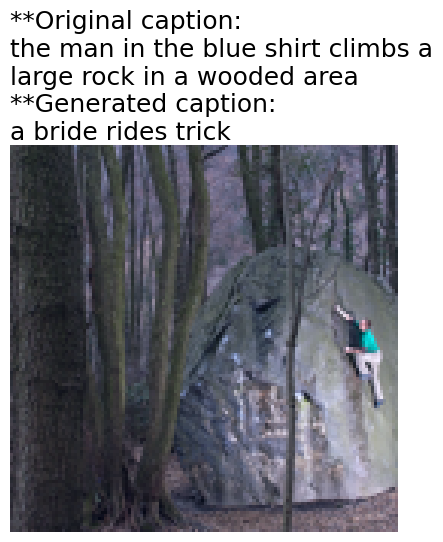

In [ ]:
from torch.distributions import Categorical
import torchvision
import matplotlib.pyplot as plt



compare(test_images,test_tokens, 9, temp=0.95)#aici-----------